In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [2]:

X, y = make_classification(n_samples=2000, n_features=15, n_informative=10, 
                           n_redundant=2, n_clusters_per_class=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [3]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(grid_search.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


0.9245


Text(0.5, 1.0, 'Confusion Matrix')

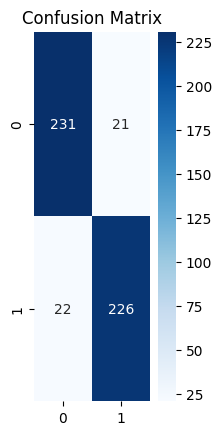

In [5]:
cv_scores = cross_val_score(best_model, X, y, cv=5)
print(f"{cv_scores.mean():.4f}")

ax1 = plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')


C:\Users\Rouzb\AppData\Local\Temp\ipykernel_17544\3671738375.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=[f'Feat_{i}' for i in range(15)], ax=ax2, palette='magma')


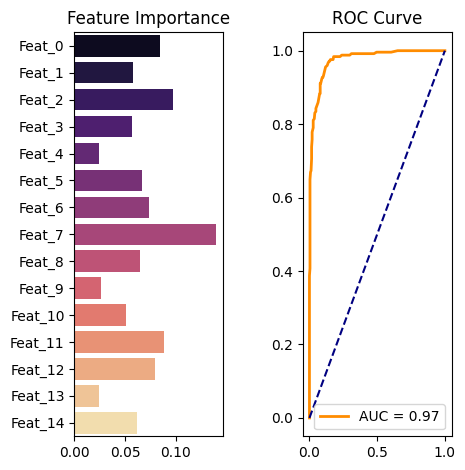

In [7]:
ax2 = plt.subplot(1, 3, 2)
importances = best_model.feature_importances_
sns.barplot(x=importances, y=[f'Feat_{i}' for i in range(15)], ax=ax2, palette='magma')
ax2.set_title('Feature Importance')

ax3 = plt.subplot(1, 3, 3)
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc(fpr, tpr):.2f}')
ax3.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax3.set_title('ROC Curve')
ax3.legend(loc="lower right")

plt.tight_layout()
plt.show()